In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import SimpleRNN, Dense , Dropout
from tensorflow.keras.models import Sequential
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
data = pd.read_csv('Google_Stock_Price_Train.csv',thousands=",")
data.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,7380500
1,1/4/2012,331.27,333.87,329.08,666.45,5749400
2,1/5/2012,329.83,330.75,326.89,657.21,6590300
3,1/6/2012,328.34,328.77,323.68,648.24,5405900
4,1/9/2012,322.04,322.29,309.46,620.76,11688800


In [3]:
data.dtypes

Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

In [4]:
data['Date']= pd.to_datetime(data['Date'])

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1258 non-null   datetime64[ns]
 1   Open    1258 non-null   float64       
 2   High    1258 non-null   float64       
 3   Low     1258 non-null   float64       
 4   Close   1258 non-null   float64       
 5   Volume  1258 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 59.1 KB


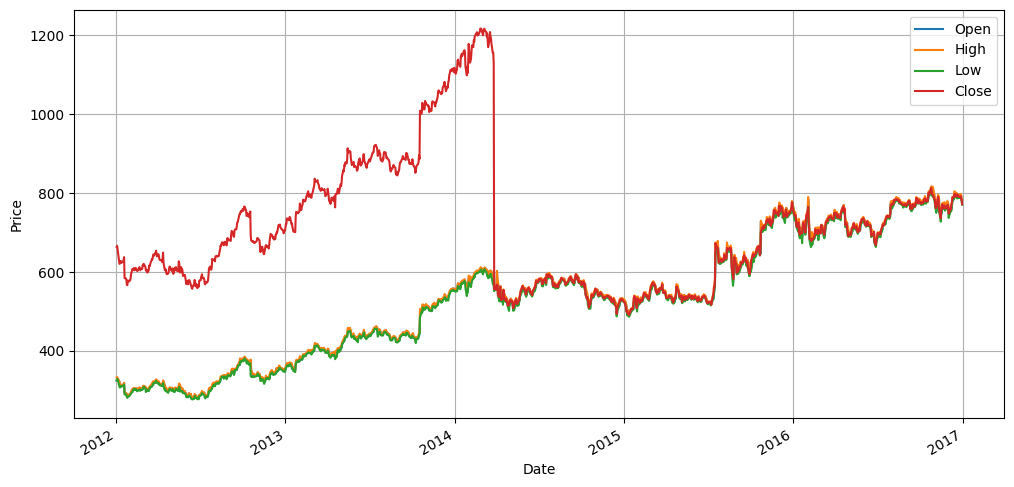

In [6]:
data.plot(x='Date',y=['Open','High','Low','Close'],figsize=(12,6))
plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [7]:
data.shape

(1258, 6)

In [8]:
data.drop('Date',inplace=True,axis=1)

In [9]:
data.shape

(1258, 5)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1258 non-null   float64
 1   High    1258 non-null   float64
 2   Low     1258 non-null   float64
 3   Close   1258 non-null   float64
 4   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 49.3 KB


In [11]:
sc= MinMaxScaler()
data_sc = sc.fit_transform(data)

In [12]:
def create_seq(data,idx,seq_len=60):
    x,y=[],[]
    for i in range(seq_len,len(data)):
        x.append(data[i-seq_len:i])
        y.append(data[i,idx])
    return np.array(x),np.array(y)
x,y=create_seq(data_sc,3)

In [13]:
x

array([[[0.08581368, 0.09640129, 0.09044931, 0.23757287, 0.29525831],
        [0.09701243, 0.09834351, 0.09823458, 0.24151427, 0.22993592],
        [0.09433366, 0.09251685, 0.09408623, 0.22878051, 0.26361233],
        ...,
        [0.07846566, 0.07903337, 0.0783452 , 0.21546794, 0.14593512],
        [0.08034452, 0.08276841, 0.08330808, 0.21229828, 0.16105326],
        [0.08497656, 0.08751191, 0.08921806, 0.22430164, 0.20379656]],

       [[0.09701243, 0.09834351, 0.09823458, 0.24151427, 0.22993592],
        [0.09433366, 0.09251685, 0.09408623, 0.22878051, 0.26361233],
        [0.09156187, 0.08881917, 0.08800576, 0.21641884, 0.21617942],
        ...,
        [0.08034452, 0.08276841, 0.08330808, 0.21229828, 0.16105326],
        [0.08497656, 0.08751191, 0.08921806, 0.22430164, 0.20379656],
        [0.08627874, 0.08564439, 0.08283452, 0.21420007, 0.15438526]],

       [[0.09433366, 0.09251685, 0.09408623, 0.22878051, 0.26361233],
        [0.09156187, 0.08881917, 0.08800576, 0.21641884, 0.2

In [14]:
y

array([0.21420007, 0.20434657, 0.21216047, ..., 0.40495845, 0.40184391,
       0.38672602])

In [15]:
split = int(len(x)*0.8)
x_train,x_test = x[:split],x[split:]
y_train,y_test = y[:split],y[split:]

In [16]:
model =Sequential()
model.add(SimpleRNN(units=50,activation = "tanh", return_sequences = True, input_shape = (x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.2))
model.add(SimpleRNN(units=50,activation = "tanh", return_sequences = True))
model.add(Dropout(0.2))
model.add(SimpleRNN(units=50,activation = "tanh", return_sequences = True))
model.add(Dropout(0.2))
model.add(SimpleRNN(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))
model.compile(optimizer='adam',loss='mse')
model.summary()

C:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 60, 50)              │           2,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 60, 50)              │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 60, 50)              │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,001 (70.32 KB)

 Trainable params: 18,001 (70.32 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
h = model.fit(
    x_train,y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test,y_test)
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.4637 - val_loss: 0.0026
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.3037 - val_loss: 0.0072
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.1993 - val_loss: 0.0099
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.1682 - val_loss: 0.0052
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.1244 - val_loss: 0.0254
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.1122 - val_loss: 7.1693e-04
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.1168 - val_loss: 7.8080e-04
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0882 - val_loss: 0.0018
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0751 - val_loss: 0.0117
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0633 - val_loss: 7.1973e-04
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0571 - val_loss: 0.0013
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step

In [18]:
close_scaler =MinMaxScaler()
close_scaler.min_,close_scaler.scale_ = sc.min_[3:4],sc.scale_[3:4]

In [19]:
y_pred = model.predict(x_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


In [20]:
predicted_values = close_scaler.inverse_transform(y_pred)
actual_values = close_scaler.inverse_transform(y_test.reshape(-1,1))

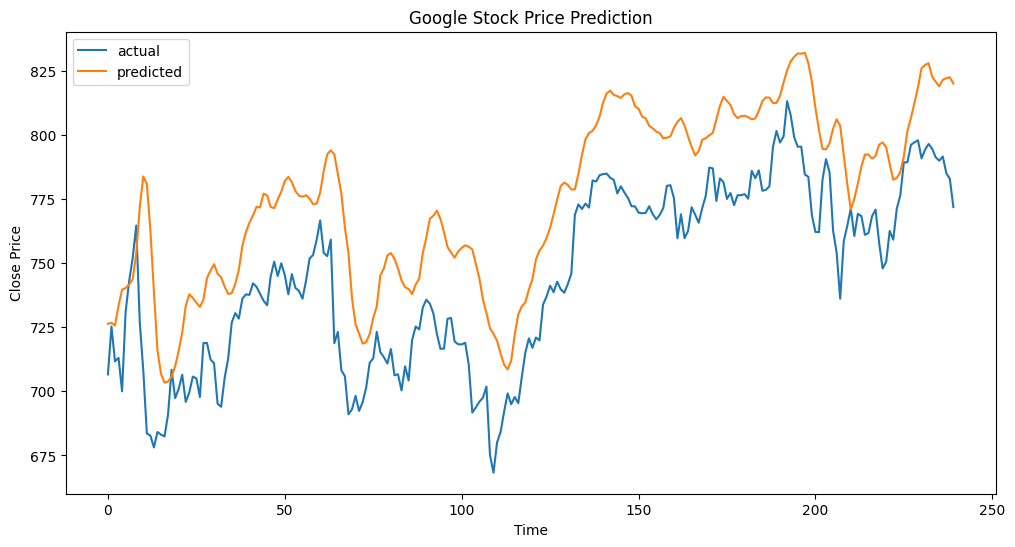

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(actual_values, label='actual')
plt.plot(predicted_values, label='predicted')
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [22]:
rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
mae = mean_absolute_error(actual_values, predicted_values)
r2 = r2_score(actual_values, predicted_values)
print('RMSE: ', rmse)
print('MAE: ', mae)
print('R2 Score: ', r2)

RMSE:  33.92773665732673
MAE:  30.677972035725915
R2 Score:  0.03598090464337822


In [39]:
# For LSTM 
from tensorflow.keras.layers import LSTM
model_l=Sequential()
model_l.add(LSTM(64,return_sequences=True,input_shape=(x_train.shape[1],x_train.shape[2])))
model_l.add(Dropout(0.2))
model_l.add(LSTM(64))
model_l.add(Dropout(0.1))
model_l.add(Dense(1))
model_l.compile(optimizer='adam',loss='mean_squared_error')
model_l.summary()

C:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 60, 64)              │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,009 (199.25 KB)

 Trainable params: 51,009 (199.25 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
h_lstm = model_l.fit(
    x_train,y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test,y_test)
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0397 - val_loss: 0.0012
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0107 - val_loss: 0.0015
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0051 - val_loss: 0.0083
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0057 - val_loss: 5.6685e-04
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0042 - val_loss: 9.4763e-04
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0048 - val_loss: 7.6569e-04
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.0065 - val_loss: 0.0029
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0045 - val_loss: 6.6625e-04
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0039 - val_loss: 0.0015
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0029 - val_loss: 4.8392e-04
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0028 - val_loss: 0.0017
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 7

In [41]:
y_pred_lstm = model_l.predict(x_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step


In [42]:
predicted_values = close_scaler.inverse_transform(y_pred_lstm)
actual_values = close_scaler.inverse_transform(y_test.reshape(-1,1))

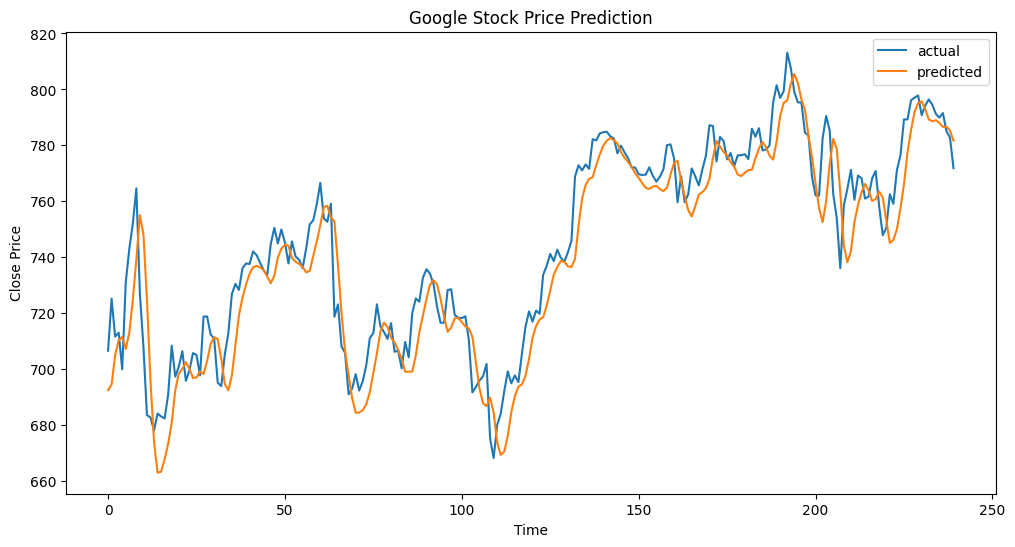

In [43]:
plt.figure(figsize=(12, 6))
plt.plot(actual_values, label='actual')
plt.plot(predicted_values, label='predicted')
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [44]:
rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
mae = mean_absolute_error(actual_values, predicted_values)
r2 = r2_score(actual_values, predicted_values)

print('RMSE: ', rmse)
print('MAE: ', mae)
print('R2 Score: ', r2)

RMSE:  12.78722568791203
MAE:  9.783500549316408
R2 Score:  0.8630605686488358
